## TSNE

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/all_low_level_features_merged.csv')

In [3]:
df['capture_id'].value_counts().max()

32

In [4]:
df.columns

Index(['frame_number', 'delta_time', 'packet_length', 'packet_direction',
       'header_form', 'count_initial', 'count_0rtt', 'count_handshake',
       'count_1rtt', 'count_retry', 'count_vn', 'count_ack', 'count_padding',
       'count_connection_close', 'count_path_challenge', 'count_path_response',
       'count_new_connection_id', 'count_retire_cid', 'count_ping',
       'count_crypto', 'count_handshake_done', 'http3_stream_count',
       'http3_fin_count', 'stream_length', 'stream_type_count', 'capture_id'],
      dtype='object')

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_tsne(real_seqs, synth_seqs):
    # Flatten sequences: (Batch, Seq_Len, Feats) -> (Batch, Seq_Len*Feats)
    real_flat = real_seqs.reshape(real_seqs.shape[0], -1)
    synth_flat = synth_seqs.reshape(synth_seqs.shape[0], -1)

    # Combine
    data = np.concatenate([real_flat, synth_flat], axis=0)
    labels = np.array([0] * len(real_flat) + [1] * len(synth_flat))

    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    embedded = tsne.fit_transform(data)

    # Plot
    plt.figure(figsize=(8, 8))
    plt.scatter(embedded[labels==0, 0], embedded[labels==0, 1], c='blue', label='Real', alpha=0.3, s=10)
    plt.scatter(embedded[labels==1, 0], embedded[labels==1, 1], c='red', label='Synthetic', alpha=0.3, s=10)
    plt.legend()
    plt.title("t-SNE Visualization: Real vs Synthetic Manifold")
    plt.show()

Real Data Shape: (11786, 10, 24)
Synth Data Shape: (11897, 10, 24)


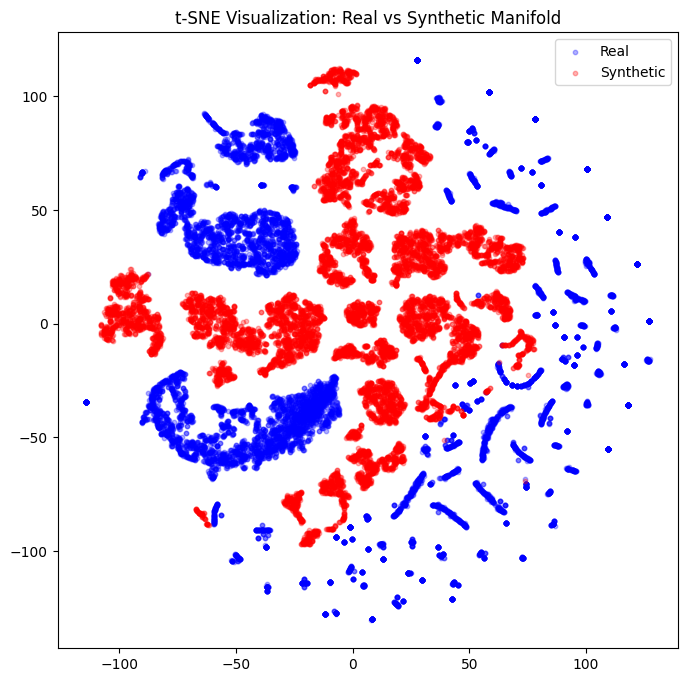

In [6]:
import pandas as pd
import numpy as np

def load_and_process_data(csv_path, max_len=20):
    """
    Transforms packet-level CSV into flow-level 3D array.
    """
    # 1. Load Data
    df = pd.read_csv(csv_path)
    df = df[~df['capture_id'].isin(df.loc[df.lt(0).any(axis=1), 'capture_id'])]

    id_col = 'capture_id'      # Identifies the flow
    order_col = 'frame_number'     # Identifies packet order
    feature_cols = ['delta_time', 'packet_length',
       'packet_direction', 'header_form', 'count_initial', 'count_0rtt',
       'count_handshake', 'count_1rtt', 'count_retry', 'count_vn', 'count_ack',
       'count_padding', 'count_connection_close', 'count_path_challenge',
       'count_path_response', 'count_new_connection_id', 'count_retire_cid',
       'count_ping', 'count_crypto', 'count_handshake_done',
       'http3_stream_count', 'http3_fin_count', 'stream_length',
       'stream_type_count'] # Add your actual feature names

    # 3. Group and Sort
    # We group by flow ID and sort packets by time/frame_id to ensure order is preserved
    grouped = df.sort_values(order_col).groupby(id_col)

    sequences = []

    # 4. Pad or Truncate each flow to MAX_LEN
    for capture_id, group in grouped:
        # Extract features as a numpy matrix (N_packets x N_features)
        seq = group[feature_cols].values

        # TRUNCATE: If sequence is too long, cut it off
        if len(seq) > max_len:
            seq = seq[:max_len, :]

        # PAD: If sequence is too short, pad with zeros
        elif len(seq) < max_len:
            # Calculate how much padding is needed
            pad_len = max_len - len(seq)
            # Create a block of zeros: (Padding_Amount, N_Features)
            padding = np.zeros((pad_len, len(feature_cols)))
            # Stack original sequence on top of padding
            seq = np.vstack([seq, padding])

        sequences.append(seq)

    # 5. Convert list of arrays to a single 3D Numpy Block
    # Result Shape: (Number_of_Flows, MAX_LEN, Number_of_Features)
    return np.array(sequences)

# --- Usage ---
real_data_path = "/content/all_low_level_features_merged.csv"
synth_data_path = "/content/synthetic_low_level_sequences_model5.csv" # If you have a CSV for this too

# Convert
real_seqs = load_and_process_data(real_data_path, max_len=10)
synth_seqs = load_and_process_data(synth_data_path, max_len=10)


print(f"Real Data Shape: {real_seqs.shape}")   # e.g., (1000, 20, 3)
print(f"Synth Data Shape: {synth_seqs.shape}") # e.g., (1000, 20, 3)

# Run your visualization
visualize_tsne(real_seqs, synth_seqs)

## CDF

In [ ]:
real_data_path = "/content/all_low_level_features_merged.csv"
synth_data_path = "/content/synthetic_low_level_sequences_model5.csv" # If you have a CSV for this too

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_distributions(real_data, synthetic_data, feature_name="Packet Size"):
    """
    Plots the CDF of a specific feature for Real vs Synthetic data.
    """
    plt.figure(figsize=(8, 5))

    # Plot Real
    sns.ecdfplot(real_data, label='Real', color='blue', linewidth=2)

    # Plot Synthetic
    sns.ecdfplot(synthetic_data, label='Synthetic', color='orange', linestyle='--', linewidth=2)

    plt.title(f'CDF Comparison: {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Cumulative Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
real_df = pd.read_csv(real_data_path)
synth_df = pd.read_csv(synth_data_path)
synth_df = synth_df[~synth_df['capture_id'].isin(synth_df.loc[synth_df.lt(0).any(axis=1), 'capture_id'])]
real_df = real_df[~real_df['capture_id'].isin(real_df.loc[real_df.lt(0).any(axis=1), 'capture_id'])]

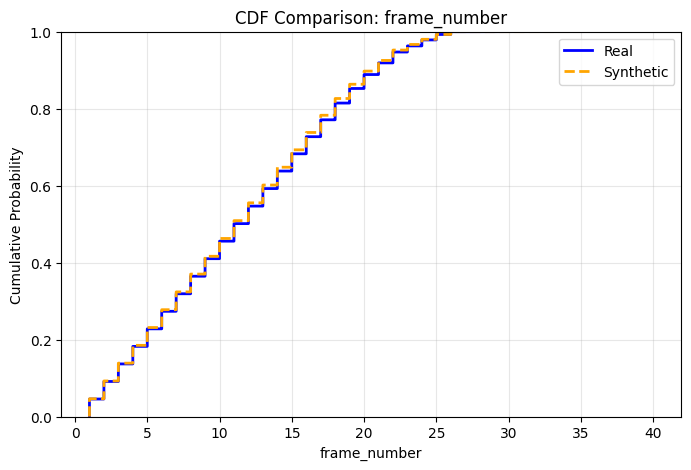

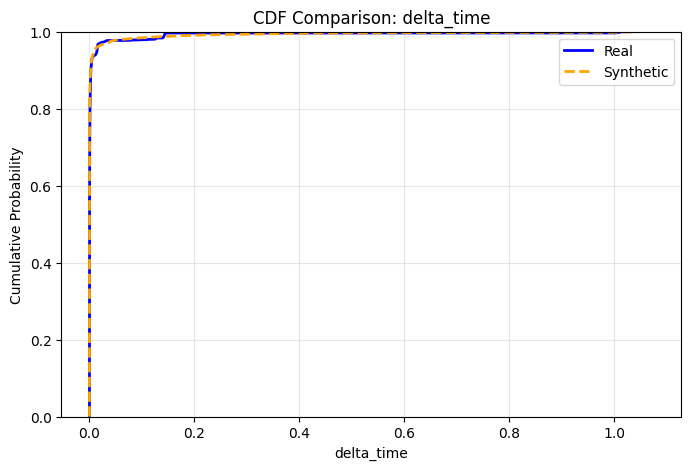

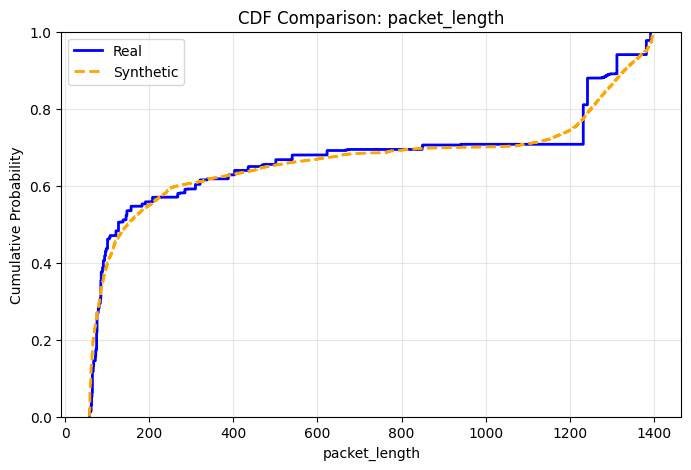

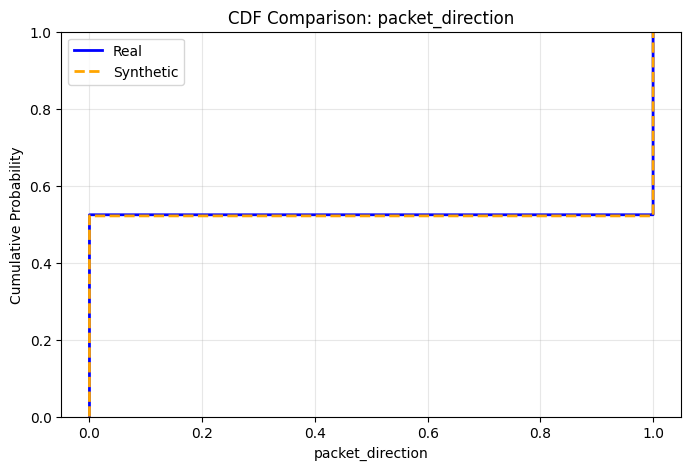

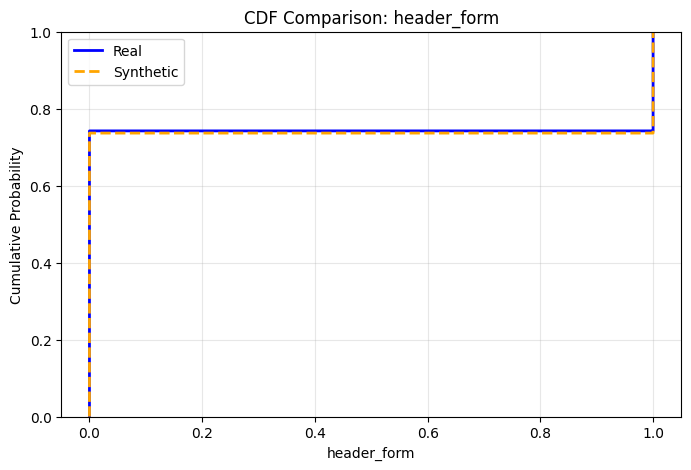

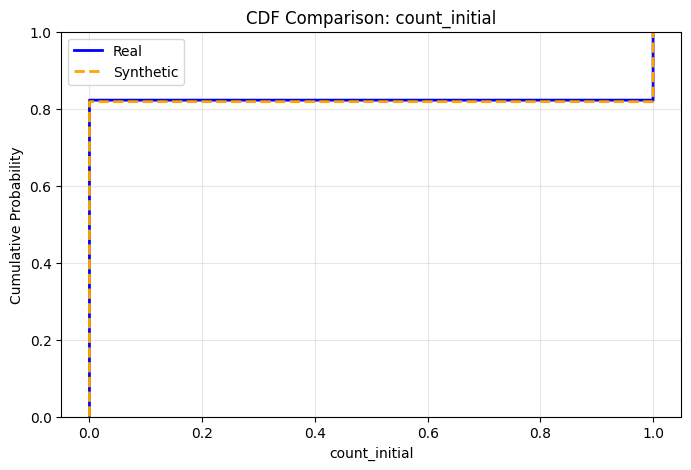

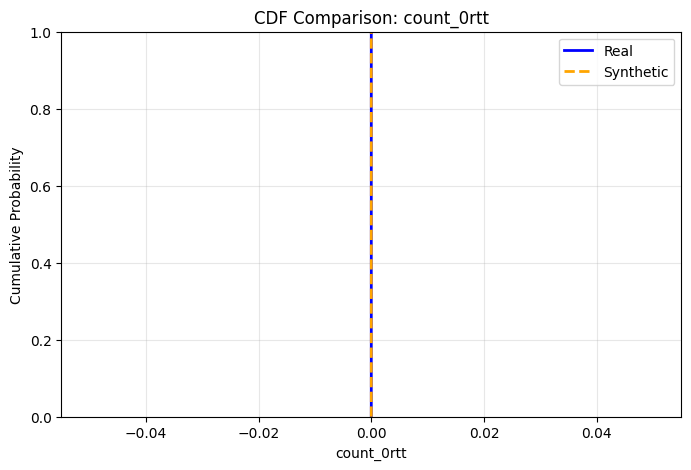

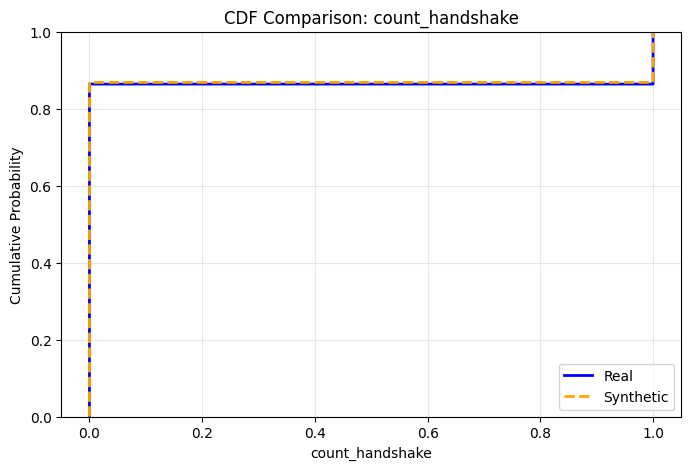

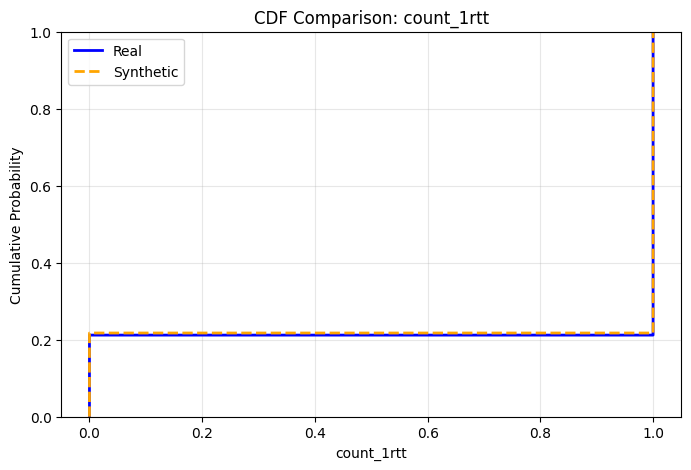

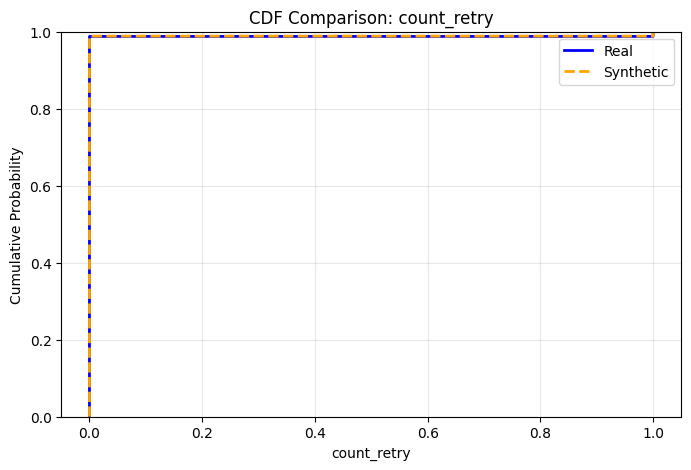

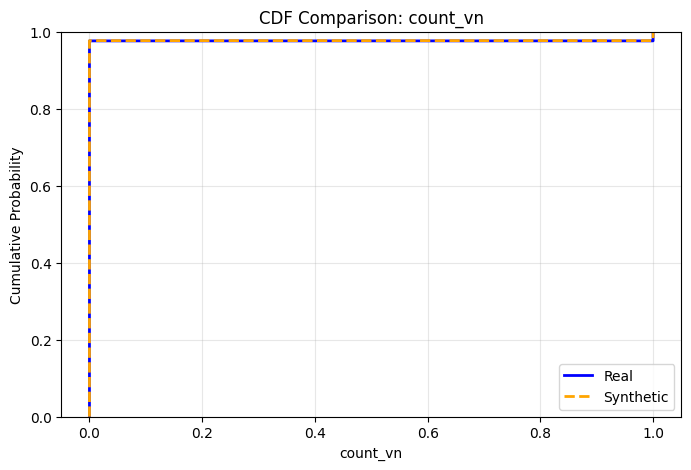

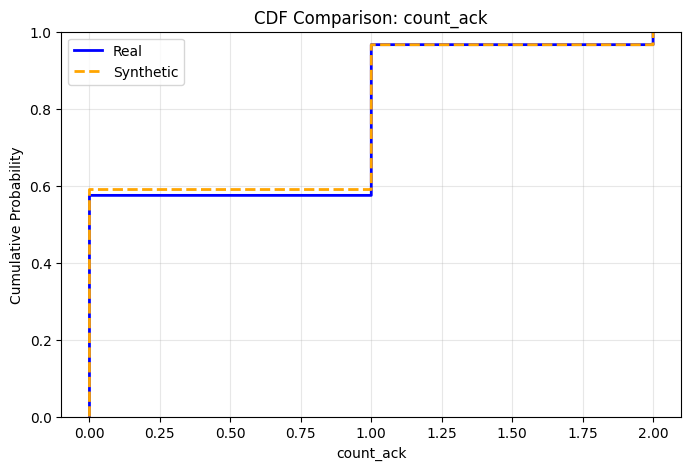

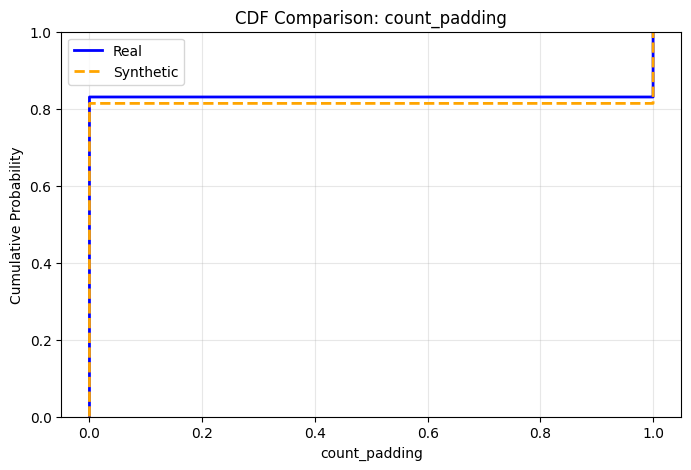

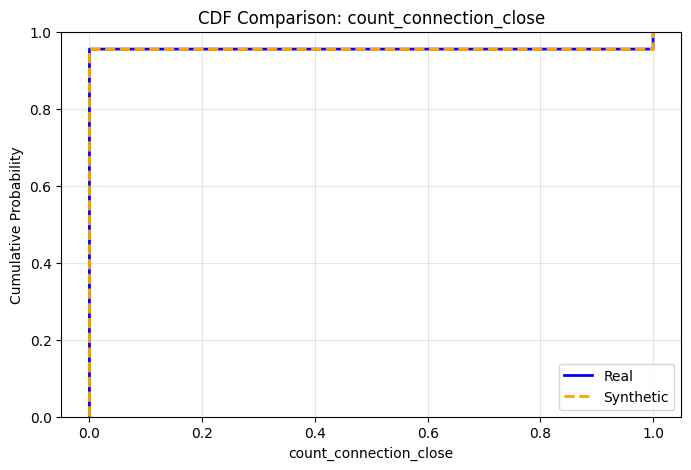

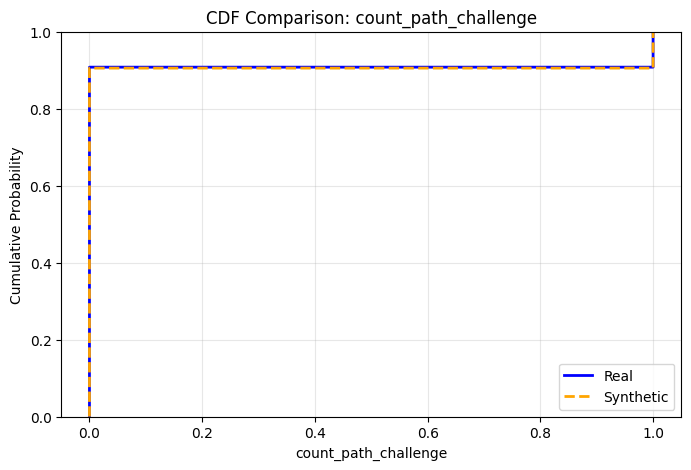

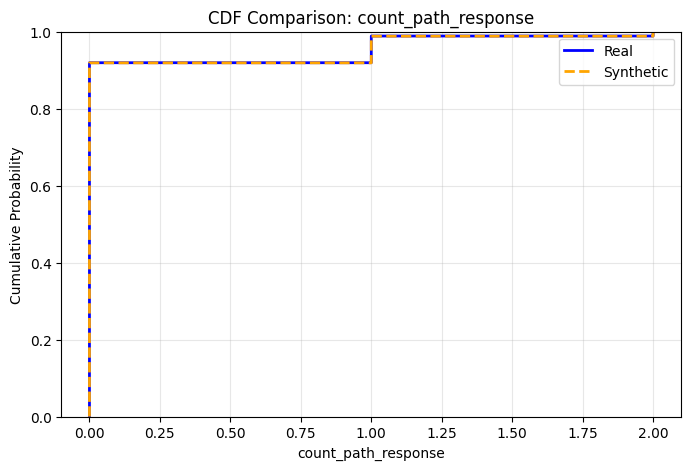

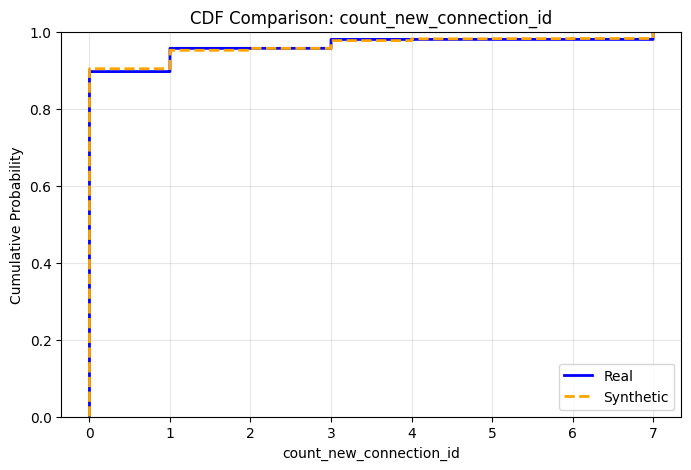

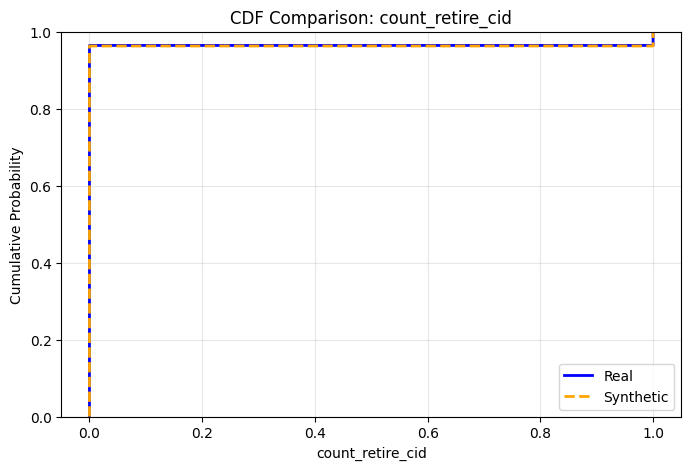

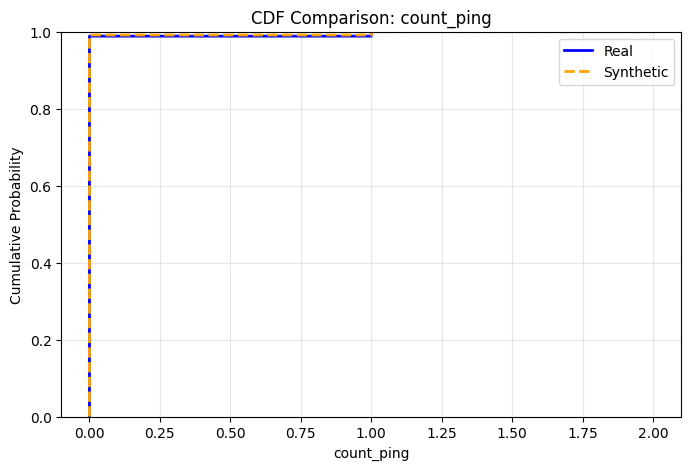

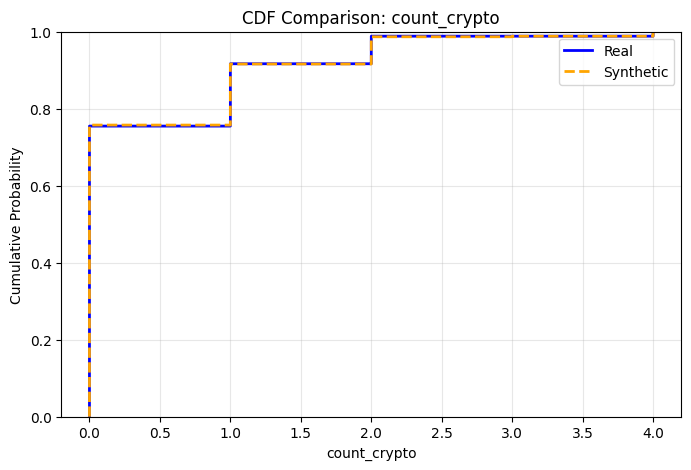

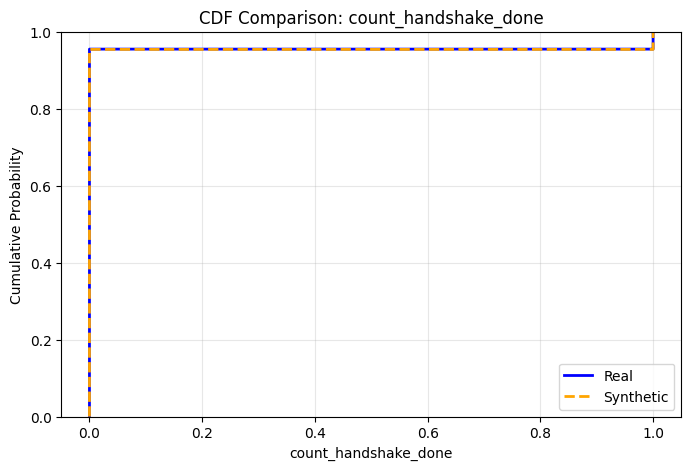

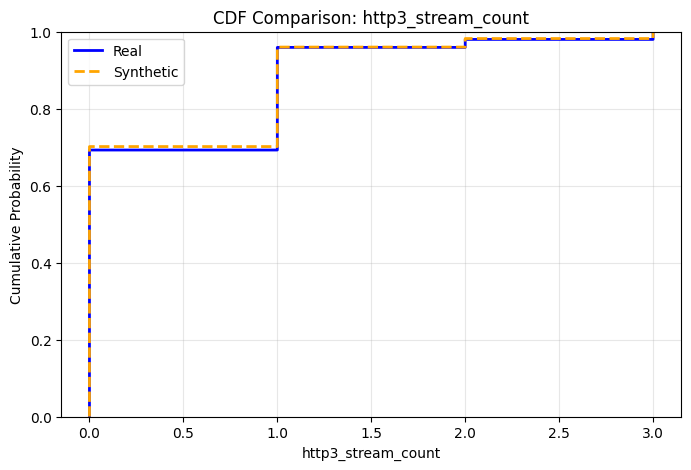

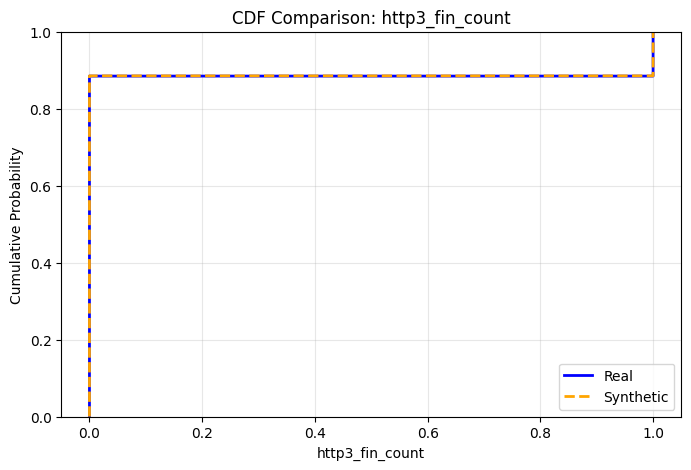

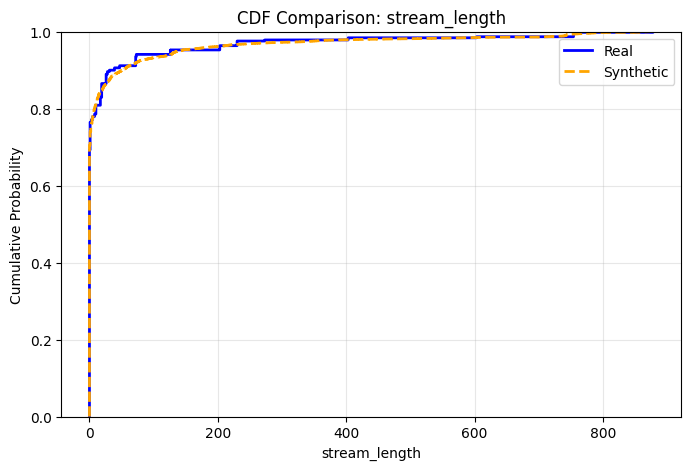

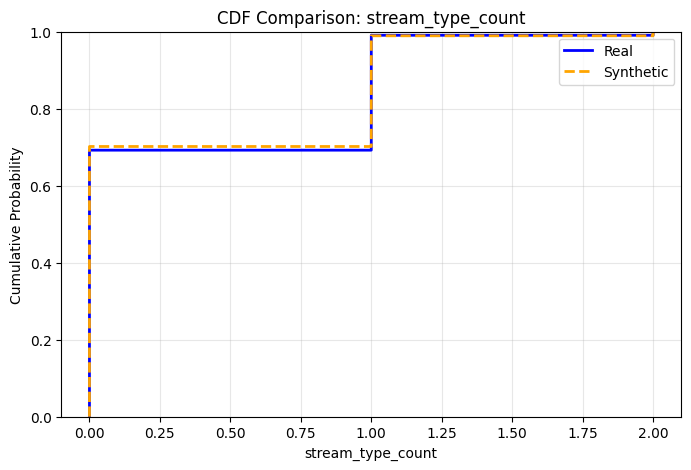

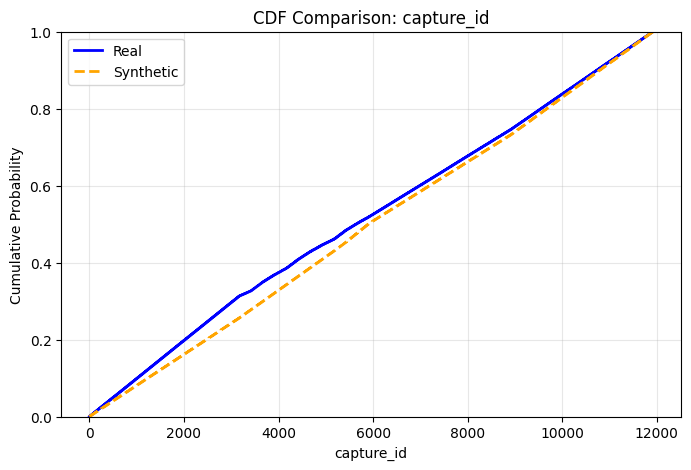

In [ ]:
cols = real_df.columns
for col in cols:
  real = real_df[col]
  synth = synth_df[col]
  plot_distributions(real, synth, col)

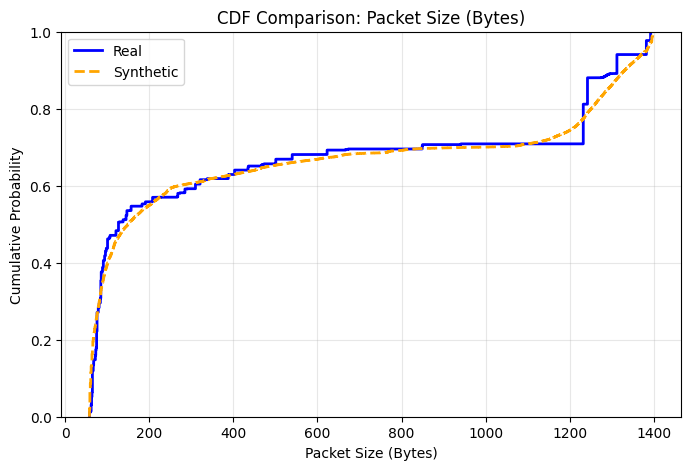

In [ ]:
real_sizes = real_df['packet_length']
synth_sizes = synth_df['packet_length']

# 3. Call your function
plot_distributions(real_sizes, synth_sizes, feature_name="Packet Size (Bytes)")

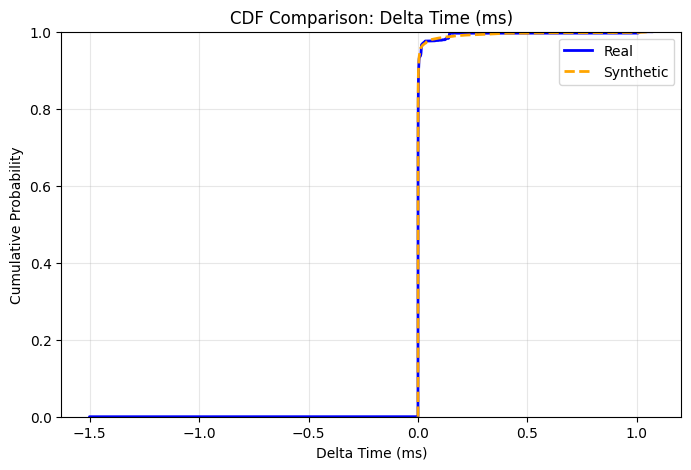

In [ ]:
real_deltas = real_df['delta_time']
synth_deltas = synth_df['delta_time']

# 3. Call your function
plot_distributions(real_deltas, synth_deltas, feature_name="Delta Time (ms)")

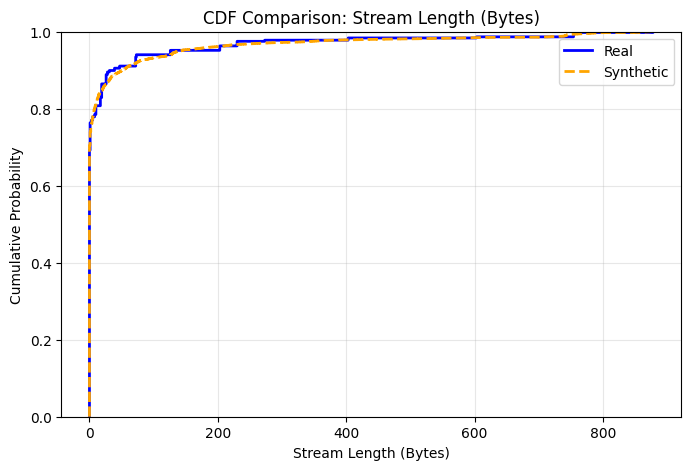

In [ ]:
real_stream_length = real_df['stream_length']
synth_stream_length = synth_df['stream_length']

# 3. Call your function
plot_distributions(real_stream_length, synth_stream_length, feature_name="Stream Length (Bytes)")